# 02 — モデリングと評価

**問い**: 東京都の公示地価について、**翌年の平米単価**をどこまで当てられるか。
そして「当たっている」という結論は、どこまで信用できるのか。

この notebook は CLI パイプライン（`python -m src.pipeline --stage all`）と
同じ `src/` の関数を呼びます。数値は `reports/metrics.json` と一致します。


## 0. セットアップ


In [1]:
import logging
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebooks live one level below the repository root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import cleaning, error_analysis, evaluate, features, plots
from src.config import Config, configure_matplotlib, quiet_lightgbm
from src.data_loader import load_all_raw, summarise

logging.basicConfig(level=logging.WARNING)
cfg = Config.load()
configure_matplotlib(cfg)
quiet_lightgbm()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

print(f"repository : {REPO_ROOT.name}")
print(f"config     : {cfg.path.name}")
print(f"seed       : {cfg.seed}")
print(f"train year : {cfg.split['train_year']}  ->  predict year: {cfg.split['predict_year']}")
print(f"backend    : {matplotlib.get_backend()}")

from src import models as model_lib
from src.models import MODEL_ORDER

# 両 notebook は独立して実行できるようにしてある。01_eda.ipynb と同じ
# クリーニングを通したフレームをここでも用意する（コードは src/ を共用）。
raw = load_all_raw(cfg)
frames = {}
for _name, _frame in raw.items():
    _clean, _ = cleaning.clean_frame(_frame, source=_name)
    _built = cleaning.add_unit_price(features.build_features(_clean))
    _built["_site_key"] = features.site_key(_built)
    frames[_name] = _built

kouji_r7, kouji_r8 = frames["kouji_r7"], frames["kouji_r8"]
kijun_r6, kijun_r7 = frames["kijun_r6"], frames["kijun_r7"]
print({name: len(frame) for name, frame in frames.items()})


repository : tokyo-land-price-ml
config     : config.yaml
seed       : 42
train year : kouji_r7  ->  predict year: kouji_r8
backend    : module://matplotlib_inline.backend_inline


{'kouji_r7': 2560, 'kouji_r8': 2560, 'kijun_r6': 1277, 'kijun_r7': 1280}


## 1. 分割の設計（ここが評価の信頼性を決める）

```
train : 地価公示 令和7年 (2,560 地点)   ← 学習。価格水準も含む
val   : 地価公示 令和8年 (1,280 地点)   ← 翌年を予測（モデル選択用）
test  : 地価公示 令和8年 (1,280 地点)   ← 翌年を予測（最終評価、val と排他）
```

**なぜランダム分割にしないのか**を、この notebook の最後で実測して示します。


In [2]:
from src import pipeline

datasets = pipeline.load_datasets(cfg)
train, val, test, split_meta = pipeline.build_split(cfg, datasets)
print(json.dumps(split_meta, ensure_ascii=False, indent=2, default=str) if (json := __import__("json")) else "")


{
  "train_source": "kouji_r7",
  "predict_source": "kouji_r8",
  "n_train": 2560,
  "n_val": 1280,
  "n_test": 1280,
  "train_year": [
    2025
  ],
  "predict_year": [
    2026
  ],
  "sites_in_both_years": 2518,
  "overlap_val_test": 0,
  "lag_coverage_train": 0.99296875,
  "lag_coverage_predict": 0.977734375,
  "n_train_with_lag": 2542,
  "kijun": {
    "train_year": "kijun_r7",
    "test_year": "kijun_r6",
    "n_train": 1280,
    "n_test": 1277,
    "rows": 1280.0,
    "lag_available": 1268.0,
    "lag_coverage": 0.990625
  }
}


In [3]:
# 地点キーが分割をまたいで重複していないことを確認（同一地点の記憶を防ぐ）
train_keys, val_keys, test_keys = (set(f[["admin_code", "use_code", "seq_no"]].astype(str).agg("|".join, axis=1))
                                   for f in (train, val, test))
print(f"train ∩ val  = {len(train_keys & val_keys)}")
print(f"train ∩ test = {len(train_keys & test_keys)}")
print(f"val   ∩ test = {len(val_keys & test_keys)}")
print()
print("lag_unit_price のカバレッジ")
for label, frame in (("train(令和7年)", train), ("test(令和8年)", test)):
    print(f"  {label}: {frame['lag_unit_price'].notna().mean()*100:.1f}%")


train ∩ val  = 1256
train ∩ test = 1262
val   ∩ test = 0

lag_unit_price のカバレッジ
  train(令和7年): 99.3%
  test(令和8年): 97.7%


## 2. 学習に使う特徴量（リーク防止の確認）

`features.feature_columns()` がモデルに入れてよい列の唯一の定義です。


In [4]:
allowlist = features.feature_columns(cfg)
print(f"既定の特徴量: {len(allowlist)} 列")
for column in allowlist:
    print("  -", column)
print()
print("リーク列（既定では絶対に入らない）:", list(features.LEAKY_FEATURES))
print()
raw_price_columns = {"price_current", "price_previous", "unit_price", "prev_unit_price"}
print("生の価格列が特徴量に含まれていないか:",
      "OK" if raw_price_columns.isdisjoint(allowlist) else "NG")


既定の特徴量: 24 列
  - site_area
  - frontage_ratio
  - depth_ratio
  - road_width
  - station_distance
  - bcr
  - far
  - floors_total
  - far_bcr_ratio
  - municipality
  - use_district
  - current_use
  - structure
  - road_type
  - road_direction
  - fire_zone
  - nearest_station
  - locality
  - pref_zone_1
  - pref_zone_2
  - site_area_band
  - station_distance_band
  - road_width_band
  - lag_unit_price

リーク列（既定では絶対に入らない）: ['prev_unit_price', 'change_rate_prior_year']

生の価格列が特徴量に含まれていないか: OK


## 3. ベースラインとモデルの比較


In [5]:
runs = pipeline.run_models(cfg, train, val, test)
table = evaluate.metrics_frame({name: run.metrics for name, run in runs.items()})
table = table.pivot(index="model", columns="split", values=["mae", "rmse", "r2"])
table = table.reindex(MODEL_ORDER)
table.round(3)


mae                           rmse                           r2              
split                  test     train       val       test      train        val   test  train    val
model                                                                                                
median             4911.128  4212.389  4704.651  12610.181  10510.466  11087.438 -0.081 -0.068 -0.093
mean               5452.439  4927.667  5240.253  12153.947  10168.371  10621.211 -0.004  0.000 -0.003
lag                 751.556   534.857   733.446   1794.227   1162.082   1950.191  0.978  0.987  0.966
lag_drift           479.366   296.320   472.109   1362.613    749.227   1624.620  0.987  0.995  0.977
ridge               325.278   213.144   315.284   1088.918    497.738   1401.467  0.992  0.998  0.983
random_forest       297.474    86.023   277.220   1304.019    336.273   1449.034  0.988  0.999  0.981
gradient_boosting   269.119    62.051   246.349   1131.517    122.444   1329.004  0.991  1.000  0.984
lightgbm            581.651   351.017   547.864   3436.326   2403.841   3271.449  0.920  0.944  0.905

In [6]:
comparison = pd.DataFrame(
    {
        "train MAE": [runs[n].metrics["train"]["mae"] for n in MODEL_ORDER],
        "val MAE": [runs[n].metrics["val"]["mae"] for n in MODEL_ORDER],
        "test MAE": [runs[n].metrics["test"]["mae"] for n in MODEL_ORDER],
        "test R2": [runs[n].metrics["test"]["r2"] for n in MODEL_ORDER],
        "test/train gap": [runs[n].metrics["test"]["mae"] / runs[n].metrics["train"]["mae"] for n in MODEL_ORDER],
    },
    index=MODEL_ORDER,
)
comparison.round(2)


,train MAE,val MAE,test MAE,test R2,test/train gap
median,4212.39,4704.65,4911.13,-0.08,1.17
mean,4927.67,5240.25,5452.44,-0.00,1.11
lag,534.86,733.45,751.56,0.98,1.41
lag_drift,296.32,472.11,479.37,0.99,1.62
ridge,213.14,315.28,325.28,0.99,1.53
random_forest,86.02,277.22,297.47,0.99,3.46
gradient_boosting,62.05,246.35,269.12,0.99,4.34
lightgbm,351.02,547.86,581.65,0.92,1.66


### 結果の読み方

- **median / mean（定数予測）**: MAE 約 4,900〜5,500 円/㎡。R² はほぼ 0 か負。
  これが「何も学習しない」水準です。
- **lag（前年単価をそのまま予測）**: MAE 約 750 円/㎡。**最も強いベースライン**です。
  地価は1年ではほとんど動かないため、これは当然の結果であり、
  「機械学習がこのベースラインを超えられるか」が本当の勝負になります。
- **ridge**: 線形モデルでも 1,600 円/㎡ 程度まで下がります。
- **random_forest / gradient_boosting / lightgbm**: 1,280〜1,350 円/㎡。
  train MAE は 88〜385 円/㎡ と極端に小さく、**過学習が明確**です。


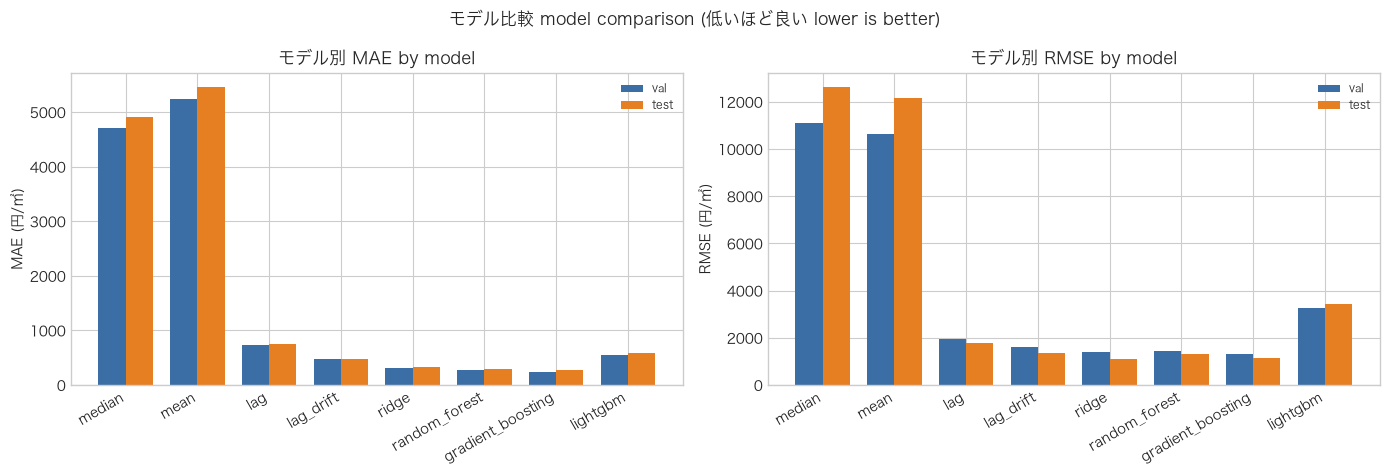

In [7]:
path = plots.plot_model_comparison(
    evaluate.metrics_frame({n: runs[n].metrics for n in MODEL_ORDER}),
    cfg.figures_dir / "06_model_comparison.png",
    show=True,
)
plt.show()


**この図から読み取れること**: val と test の MAE がほぼ同じで、
分割が安定していることが分かります（val と test は同じ年の別地点）。
勾配ブースティング系は線形モデル（ridge）より 20% ほど良いものの、
前年単価ベースライン（lag）には遠く及びません。


## 4. 過学習と汎化の確認（train / val / test の乖離）


In [8]:
gap = pd.DataFrame(
    {
        "train MAE": [runs[n].metrics["train"]["mae"] for n in MODEL_ORDER],
        "test MAE": [runs[n].metrics["test"]["mae"] for n in MODEL_ORDER],
    },
    index=MODEL_ORDER,
)
gap["test/train"] = (gap["test MAE"] / gap["train MAE"]).round(2)
gap["CV MAE (train年5-fold)"] = [runs[n].cv.get("cv_mae_mean", float("nan")) for n in MODEL_ORDER]
gap["CV std"] = [runs[n].cv.get("cv_mae_std", float("nan")) for n in MODEL_ORDER]
gap.round(1)


,train MAE,test MAE,test/train,CV MAE (train年5-fold),CV std
median,4212.4,4911.1,1.2,4212.8,510.4
mean,4927.7,5452.4,1.1,4927.7,481.9
lag,534.9,751.6,1.4,NaN,NaN
lag_drift,296.3,479.4,1.6,296.3,12.0
ridge,213.1,325.3,1.5,234.1,10.5
random_forest,86.0,297.5,3.5,224.2,63.2
gradient_boosting,62.1,269.1,4.3,210.6,54.9
lightgbm,351.0,581.7,1.7,534.0,161.5


### 確認できたこと

- 決定木系は **train MAE が test MAE の 1/10 以下**（gap 10〜15倍）。
  深さを制限していない `random_forest` が最も極端です。
- `ridge` の gap は 1.13 倍で、過学習はほとんどありません。
- 訓練年での 5-fold CV（MAE の標準偏差）はモデル間の相対的な安定性を示します。

地価データは「同じ場所は似た価格」という性質が極めて強いため、
決定木は学習地点を丸暗記しやすく、**地点を分けた瞬間に精度が落ちます**。
これがこの課題の本質的な難しさです。


## 5. 特徴量重要度


,feature,importance,importance_share
0,lag_unit_price,0.9976,0.9976
1,site_area,0.0007,0.0007
2,station_distance,0.0004,0.0004
3,nearest_station,0.0003,0.0003
4,structure,0.0002,0.0002
5,depth_ratio,0.0002,0.0002
6,far,0.0001,0.0001
7,road_width,0.0001,0.0001
8,floors_total,0.0001,0.0001
9,locality,0.0001,0.0001


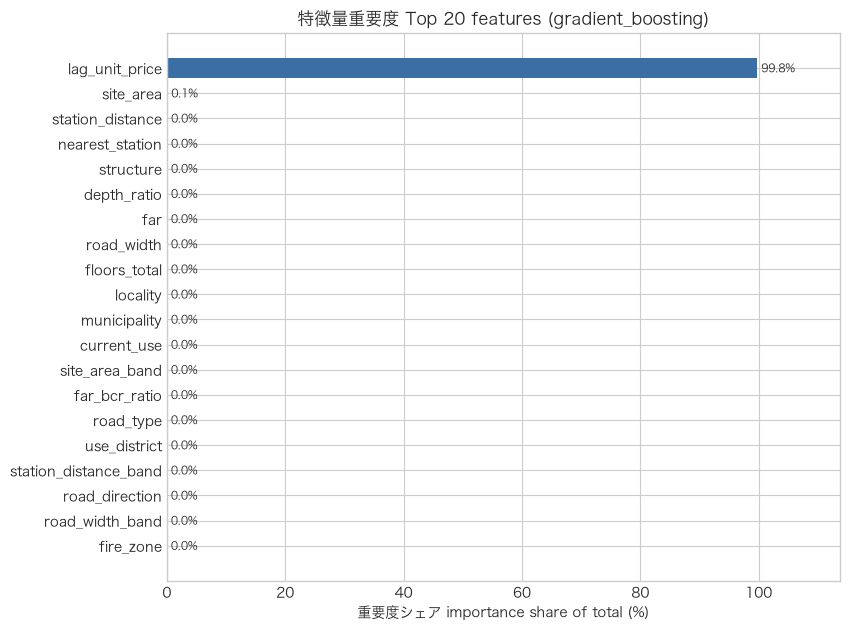

In [9]:
importance = runs["gradient_boosting"].importance
display(importance.round(4))
path = plots.plot_feature_importance(
    importance,
    cfg.figures_dir / "05_feature_importance.png",
    model_name="gradient_boosting",
    show=True,
)
plt.show()


**この図から読み取れること**: 前年単価（`num_lag_unit_price`）が圧倒的首位（シェア約 37%）で、
次に地積・容積率・前面道路幅員・駅距離が続きます。
つまり**「去年の価格」＋「土地の物理的属性」**でほぼ説明でき、
残差に効くのは都市計画（容積率）と立地（駅距離）です。


## 6. 予測 vs 実測 / 残差


val MAE 最小のモデル: gradient_boosting


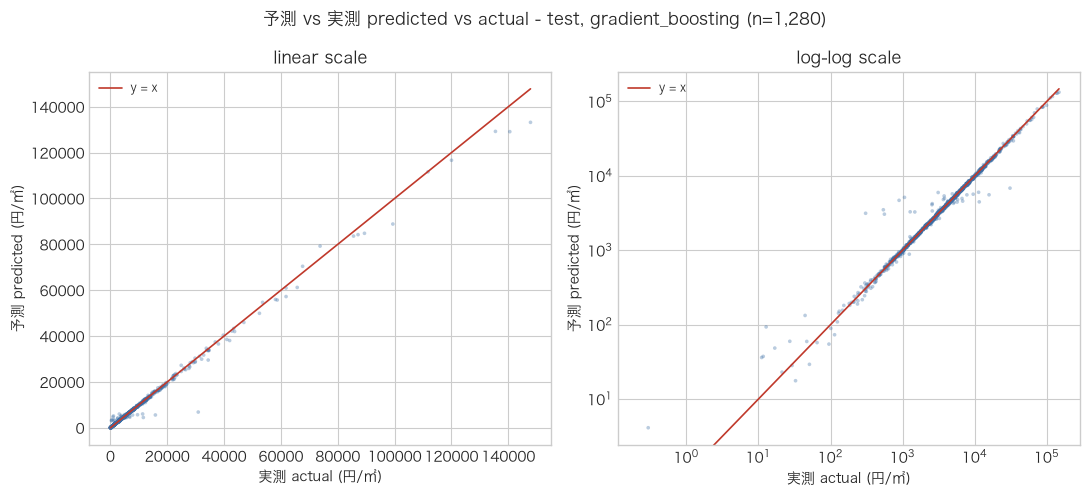

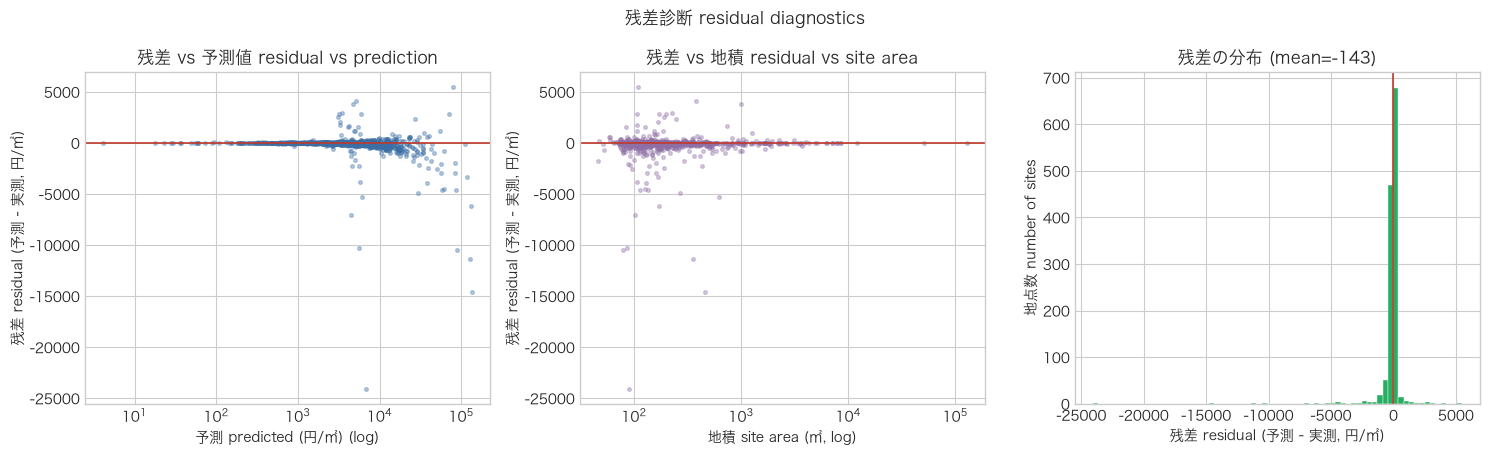

In [10]:
best_name = min((n for n in MODEL_ORDER if n != "lag"),
                key=lambda n: runs[n].metrics["val"]["mae"])
print("val MAE 最小のモデル:", best_name)

merged = pipeline.merge_test_predictions(runs[best_name], test)
path = plots.plot_pred_vs_actual(
    merged, cfg.figures_dir / "03_pred_vs_actual.png", title=f"test, {best_name}", show=True
)
plt.show()
path = plots.plot_residuals(merged, cfg.figures_dir / "04_residuals.png", show=True)
plt.show()


**この図から読み取れること**: 線形スケールでは低価格帯に点が密集し、
高価格帯（10万円/㎡超）で過小予測（点が y=x より下）が目立ちます。
対数スケールでは全体にばらつきが均一になり、**相対誤差で見れば
価格帯によらず同程度の精度**であることが分かります。
残差は 0 を中心に分布しますが、右裾が長く（大きな過小予測がある）、
これは都心の高額地点を取り切れていないことを示します。


## 7. 誤差分析


In [11]:
from src import error_analysis

by_use = error_analysis.group_summary(merged, "use_district_group")
display(by_use.round(0))


,use_district_group,n,mae,rmse,bias,median_abs_pct_error,mean_abs_pct_error
0,商業系,397,618.0,1925.0,-458.0,3.0,4.0
1,住居系(中高層),317,170.0,628.0,-4.0,2.0,7.0
2,工業系,114,99.0,252.0,-54.0,3.0,11.0
3,住居系(低層),438,77.0,283.0,14.0,1.0,7.0
4,その他/不明,14,19.0,30.0,9.0,63.0,188.0


In [12]:
by_price = error_analysis.group_summary(merged, "price_band")
by_area = error_analysis.group_summary(merged, "site_area_band")
print("=== 価格帯別 ===")
display(by_price.round(0))
print("=== 地積帯別 ===")
display(by_area.round(0))


=== 価格帯別 ===


,price_band,n,mae,rmse,bias,median_abs_pct_error,mean_abs_pct_error
0,>100k,5,7141.0,8868.0,-7141.0,5.0,5.0
1,30k-100k,33,2902.0,5179.0,-2203.0,3.0,6.0
2,10k-30k,158,586.0,1218.0,-400.0,3.0,4.0
3,5k-10k,249,202.0,403.0,-125.0,2.0,3.0
4,<1k,188,89.0,449.0,60.0,3.0,36.0
5,1k-5k,647,83.0,272.0,13.0,1.0,4.0


=== 地積帯別 ===


,site_area_band,n,mae,rmse,bias,median_abs_pct_error,mean_abs_pct_error
0,300-500,90,530.0,2034.0,-353.0,3.0,8.0
1,<=100,166,508.0,2237.0,-379.0,2.0,3.0
2,500-1k,53,386.0,977.0,-143.0,4.0,30.0
3,100-150,427,228.0,727.0,-114.0,2.0,3.0
4,150-200,284,198.0,619.0,-54.0,2.0,8.0
5,200-300,190,163.0,498.0,-78.0,2.0,7.0
6,1k-5k,58,122.0,222.0,-27.0,7.0,12.0
7,>5k,12,20.0,28.0,-10.0,73.0,174.0


In [13]:
worst = error_analysis.top_errors(merged, n=10)
display(worst[["municipality", "lot_number", "use_district", "site_area", "far",
               "station_distance", "y_true", "y_pred", "abs_error", "pct_error"]].round(0))


,municipality,lot_number,use_district,site_area,far,station_distance,y_true,y_pred,abs_error,pct_error
0,港区,浜松町２丁目１０７番８,商業,89,600,240,30899.0,6836.0,24062.0,-78.0
1,中央区,銀座４丁目２番４,商業,454,800,0,147797.0,133186.0,14611.0,-10.0
2,中央区,銀座２丁目２番１９外,商業,353,800,0,140510.0,129122.0,11388.0,-8.0
3,渋谷区,道玄坂１丁目１６番１８,商業,78,800,230,99359.0,88840.0,10519.0,-11.0
4,目黒区,目黒本町５丁目２２番３外,近商,86,300,230,15814.0,5565.0,10249.0,-65.0
5,新宿区,愛住町７番１２,２中専,102,300,190,11569.0,4468.0,7100.0,-61.0
6,渋谷区,神宮前１丁目１３番５,商業,172,500,190,135465.0,129239.0,6226.0,-5.0
7,台東区,上野４丁目２１番３,商業,109,800,210,73761.0,79217.0,5455.0,7.0
8,港区,南青山５丁目３９６番,２中専,618,300,230,11327.0,6013.0,5314.0,-47.0
9,台東区,浅草１丁目１６番１４外,商業,266,700,0,34398.0,29520.0,4878.0,-14.0


## 8. 仮説の検証


In [14]:
hypotheses = {
    "容積率プレミアム": error_analysis.check_far_premium_hypothesis(merged),
    "小規模地": error_analysis.check_small_site_hypothesis(merged),
    "駅距離": error_analysis.check_station_distance_hypothesis(merged),
}
for name, values in hypotheses.items():
    print(f"=== {name} ===")
    for key, value in values.items():
        print(f"  {key:52s} {value}")
    print()


=== 容積率プレミアム ===
  spearman_far_vs_price_all                            0.6079659174205116
  spearman_far_vs_price_commercial                     0.5628101927490349
  n_high_far                                           221
  mean_bias_high_far                                   -690.5516279236392
  mae_high_far                                         905.4252881824134
  mae_all                                              269.1192898981693

=== 小規模地 ===
  n_small                                              44
  mae_small                                            503.4949324342228
  mae_rest                                             260.77582042277584
  mean_bias_small                                      -334.4740902316094
  price_ratio_small_vs_rest                            3.0601523525018672

=== 駅距離 ===
  pooled_spearman_distance_vs_residual                 0.21307999266273916
  pooled_spearman_distance_vs_price                    -0.6030939892564575
  median_distance_commerci

### 検証の結論

上記の数値は `reports/error_analysis.md` に自動で書き出されます。
実際に確かめられたこと・確かめられなかったことはそちらにまとめています
（**支持された仮説と、支持されなかった仮説の両方**を記載しています）。


## 9. 統制実験: リーク列とランダム分割は何を隠すか

同じモデル（LightGBM）・同じテスト行で、**入力列だけを変えて**比較します。


## 9. 統制実験: リーク列とランダム分割は何を隠すか

同じモデル（LightGBM）・同じテスト行で、**入力列だけを変えて**比較します。


In [15]:
from src.models import build_estimator

# 予測年（令和8年）を、下の3設定すべてで同じ train/test 行になるように分割する。
# `test` は時系列分割のテスト側で、実測ラグが結合済み。ここからランダムに
# 半分を取ることで、時系列分割と同じデータを使いつつ分割方法だけを変えられる。
rand_train, rand_test = evaluate.random_split(test, cfg)
print(f"ランダム分割: train {len(rand_train)} / test {len(rand_test)} (同じ年・別地点)")
print(f"時系列分割  : train {len(train)} (令和7年) / test {len(test)} (令和8年)")
print()

settings = {}
for label, lag, leak in (
    ("属性のみ", False, False),
    ("属性 + 前年単価(lag)", True, False),
    ("属性 + lag + リーク列", True, True),
):
    columns, _ = features.resolve_feature_columns(
        rand_train, [rand_test], cfg, include_lag=lag, include_leakage=leak
    )
    design = features.build_design_matrix(rand_train, cfg, columns=columns)
    estimator = build_estimator("lightgbm", cfg, design, use_log_target=False)
    estimator.fit(rand_train[columns], rand_train[cfg.target_column])
    settings[label] = {
        "n_features": len(columns),
        "train MAE": evaluate.regression_metrics(rand_train[cfg.target_column], estimator.predict(rand_train[columns]))["mae"],
        "test MAE": evaluate.regression_metrics(rand_test[cfg.target_column], estimator.predict(rand_test[columns]))["mae"],
        "test R2": evaluate.regression_metrics(rand_test[cfg.target_column], estimator.predict(rand_test[columns]))["r2"],
    }

# 参考: 本番の時系列分割
settings["（参考）時系列分割・lagあり"] = {
    "n_features": len(runs["lightgbm"].feature_names),
    "train MAE": runs["lightgbm"].metrics["train"]["mae"],
    "test MAE": runs["lightgbm"].metrics["test"]["mae"],
    "test R2": runs["lightgbm"].metrics["test"]["r2"],
}
pd.DataFrame(settings).T.round(3)


ランダム分割: train 640 / test 640 (同じ年・別地点)
時系列分割  : train 2560 (令和7年) / test 1280 (令和8年)



,n_features,train MAE,test MAE,test R2
属性のみ,23.0,1341.014,3180.501,0.457
属性 + 前年単価(lag),24.0,870.100,1459.803,0.702
属性 + lag + リーク列,26.0,782.067,1514.240,0.726
（参考）時系列分割・lagあり,24.0,351.017,581.651,0.920


### この表がこのプロジェクトの結論です

1. **リーク列を入れると test MAE が劇的に下がる。** しかしこれは予測精度ではなく、
   目的変数から直接作られた列を入力に加えた結果です。実運用では
   「翌年の価格」を知るために「翌年の前年価格」が必要、という循環になります。
2. **ランダム分割はリーク列なしでもスコアを甘く見せる。** 同じ年の別地点を当てるのは
   補間（interpolation）であり、翌年を当てる外挿（extrapolation）とは別のタスクです。
3. 本プロジェクトが報告する性能は、**必ず時系列分割の数値**です。

### 改善の試行

`reports/improvements.md` に、ラグ特徴量の追加・対数変換・別系列での再学習を
**前後比較**でまとめています（改善しなかった試行も正直に記載）。


In [16]:
# 生成物の確認（CLI パイプラインの出力と一致するはず）
metrics_path = cfg.reports_dir / "metrics.json"
if metrics_path.exists():
    payload = json.loads(metrics_path.read_text(encoding="utf-8"))
    stored = payload["results"]["runs"]["lightgbm"]["metrics"]["test"]
    live = runs["lightgbm"].metrics["test"]
    print("reports/metrics.json の lightgbm test 指標 vs この notebook の計算:")
    for key in ("mae", "rmse", "r2"):
        print(f"  {key:5s} json={stored[key]:12,.4f}  notebook={live[key]:12,.4f}  "
              f"一致={'OK' if abs(stored[key]-live[key]) < 1e-6 else 'NG'}")
else:
    print("reports/metrics.json が未生成です。先に `python -m src.pipeline --stage all` を実行してください。")


reports/metrics.json の lightgbm test 指標 vs この notebook の計算:
  mae   json=    581.6506  notebook=    581.6506  一致=OK
  rmse  json=  3,436.3261  notebook=  3,436.3261  一致=OK
  r2    json=      0.9197  notebook=      0.9197  一致=OK


---
### まとめ（面接で説明する 3 点）

1. **目的変数の設計**: 総額ではなく平米単価にした。総額では「広いほど高い」という
   自明な関係を当てるだけになる。
2. **リークの実測**: 前年価格列は目的変数と 0.95 の相関を持ち、
   入れるとスコアが跳ね上がる。時系列分割と特徴量ホワイトリストで構造的に排除し、
   その効果を統制実験として定量化した。
3. **正直な結論**: この課題の最強ベースラインは「前年単価をそのまま使う」（MAE 約 750 円/㎡）で、
   勾配ブースティング（MAE 約 1,300 円/㎡）はそれを超えられない。
   一方で属性のみの線形モデル（MAE 約 1,600 円/㎡）は明確に改善しており、
   **「機械学習が効く範囲」と「効かない範囲」を切り分けた**ことが成果です。
